# Model Training on v2 Dataset

This notebook trains/evaluates a model on `micro_mobility_training_data_2025_v2.csv`, reports training time and train/test metrics, saves artifacts for later inference/reporting, and supports loading artifacts without retraining.


## ARIMAX (Per-Station SARIMAX)

This notebook fits a SARIMAX model per station using exogenous regressors.

Notes:
- Full all-station training can be slow.
- Use `station_limit` to control runtime.
- Metrics are reported on stations actually trained.


In [ ]:
import os
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from google.colab import drive

drive.mount('/content/drive')

project_folder = '/content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction'
data_path = os.path.join(project_folder, 'data/proceed/micro_mobility_training_data_2025_v2.csv')

print('data_path:', data_path)


Mounted at /content/drive
data_path: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/data/proceed/micro_mobility_training_data_2025_v2.csv


In [ ]:
import joblib
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
warnings.filterwarnings('ignore')


In [ ]:
# Load data and prep station-level frame
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])
if 'datetime_hour' in df.columns:
    df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])

sort_cols = ['station', 'datetime_hour'] if 'datetime_hour' in df.columns else ['station', 'date', 'hour']
df = df.sort_values(sort_cols).reset_index(drop=True)

exog_cols = [
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'rolling_mean_3h'
]
for c in exog_cols + ['net_demand', 'station']:
    if c not in df.columns:
        raise ValueError(f'Missing column: {c}')

if 'datetime_hour' in df.columns:
    cutoff_ts = df['datetime_hour'].max() - pd.Timedelta(days=7)
    train_mask = df['datetime_hour'] <= cutoff_ts
    test_mask = df['datetime_hour'] > cutoff_ts
    print('cutoff_ts:', cutoff_ts)
else:
    cutoff_date = df['date'].max() - pd.Timedelta(days=7)
    train_mask = df['date'] <= cutoff_date
    test_mask = df['date'] > cutoff_date
    print('cutoff_date:', cutoff_date)

print('rows total:', len(df))
print('test zero ratio:', float((df.loc[test_mask, 'net_demand'] == 0).mean()))


cutoff_ts: 2025-12-24 23:00:00
rows total: 4254919
test zero ratio: 0.9465263518138262


In [ ]:
# Train/load ARIMAX artifacts
run_training = True
station_limit = None  # set e.g. 120 for faster runs
min_train_points = 200
sarimax_order = (1, 0, 1)
artifact_dir = os.path.join(project_folder, 'artifacts/model_training/arimax/v2_0')
os.makedirs(artifact_dir, exist_ok=True)
model_path = os.path.join(artifact_dir, 'arimax_models.joblib')
metrics_path = os.path.join(artifact_dir, 'metrics.json')
predictions_path = os.path.join(artifact_dir, 'test_predictions.parquet')
stations = sorted(df['station'].dropna().unique().tolist())
if station_limit is not None:
    stations = stations[:station_limit]
models = {}
train_preds = []
test_preds = []
if run_training:
    t0 = time.perf_counter()
    fitted_count = 0
    for s in stations:
        sdf = df[df['station'] == s].copy()
        tr = sdf[train_mask.loc[sdf.index]]
        te = sdf[test_mask.loc[sdf.index]]
        if len(tr) < min_train_points or len(te) == 0:
            continue
        # Reset per-station indices so SARIMAX sees contiguous timelines.
        # This avoids shape/index mismatches when forecasting with exogenous inputs.
        y_tr = tr['net_demand'].astype('float64').reset_index(drop=True)
        X_tr = tr[exog_cols].astype('float64').reset_index(drop=True)
        X_te = te[exog_cols].astype('float64').reset_index(drop=True)
        try:
            m = SARIMAX(
                endog=y_tr,
                exog=X_tr,
                order=sarimax_order,
                trend='n',
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            res = m.fit(disp=False, maxiter=120)
        except Exception:
            continue
        models[s] = res
        fitted_count += 1
        # In-sample predictions for training window
        pred_tr = np.asarray(res.fittedvalues)
        # Out-of-sample forecast for test window using test exog
        pred_te = np.asarray(res.get_forecast(steps=len(te), exog=X_te).predicted_mean)
        train_preds.append(pd.DataFrame({'station': s, 'idx': tr.index, 'y_true': y_tr.values, 'y_pred': np.asarray(pred_tr)}))
        test_preds.append(pd.DataFrame({'station': s, 'idx': te.index, 'y_true': te['net_demand'].values, 'y_pred': np.asarray(pred_te)}))
    train_seconds = time.perf_counter() - t0
    joblib.dump(models, model_path)
    print(f'Fitted stations: {fitted_count}')
    print('Saved model bundle:', model_path)
else:
    models = joblib.load(model_path)
    train_seconds = 0.0
    print('Loaded model bundle:', model_path)


Fitted stations: 487
Saved model bundle: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/arimax/v2_0/arimax_models.joblib


In [ ]:
# Evaluate ARIMAX predictions and save artifacts
if len(train_preds) == 0 or len(test_preds) == 0:
    raise RuntimeError('No station model was fitted. Increase station_limit or lower min_train_points.')

train_df = pd.concat(train_preds, ignore_index=True)
test_df = pd.concat(test_preds, ignore_index=True)

train_rmse = float(np.sqrt(mean_squared_error(train_df['y_true'], train_df['y_pred'])))
train_mae = float(mean_absolute_error(train_df['y_true'], train_df['y_pred']))
test_rmse = float(np.sqrt(mean_squared_error(test_df['y_true'], test_df['y_pred'])))
test_mae = float(mean_absolute_error(test_df['y_true'], test_df['y_pred']))

# baselines on same evaluated test rows
test_idx = test_df['idx'].astype(int).to_numpy()
base_slice = df.loc[test_idx]
baselines = {
    'zero': np.zeros(len(base_slice), dtype=np.float32),
    'lag_1h': base_slice['lag_1h'].to_numpy(),
    'lag_24h': base_slice['lag_24h'].to_numpy(),
    'rolling_mean_3h': base_slice['rolling_mean_3h'].to_numpy(),
}
baseline_rows = []
for name, bp in baselines.items():
    baseline_rows.append({
        'model': name,
        'rmse': float(np.sqrt(mean_squared_error(base_slice['net_demand'], bp))),
        'mae': float(mean_absolute_error(base_slice['net_demand'], bp)),
    })

perf_df = pd.DataFrame([
    {'split': 'train', 'rmse': train_rmse, 'mae': train_mae},
    {'split': 'test', 'rmse': test_rmse, 'mae': test_mae},
])

print('\n--- Training Time ---')
print(f'{train_seconds:.2f} sec ({train_seconds/60:.2f} min)')
print('\n--- ARIMAX Performance ---')
display(perf_df)
print('\n--- Test Baselines (same evaluated rows) ---')
display(pd.DataFrame(baseline_rows))

test_art = test_df.merge(df[['station']].reset_index().rename(columns={'index':'idx'}), on=['station','idx'], how='left')
if 'datetime_hour' in df.columns:
    test_art = test_art.merge(df[['datetime_hour']].reset_index().rename(columns={'index':'idx'}), on='idx', how='left')

test_art.to_parquet(predictions_path, index=False)

metrics = {
    'fitted_stations': int(len(models)),
    'train_rows_eval': int(len(train_df)),
    'test_rows_eval': int(len(test_df)),
    'train_seconds': train_seconds,
    'sarimax_order': sarimax_order,
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'baseline_test': baseline_rows,
    'model_path': model_path,
    'predictions_path': predictions_path,
}
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

print('\nSaved artifacts:')
print('-', model_path)
print('-', metrics_path)
print('-', predictions_path)



--- Training Time ---
3797.26 sec (63.29 min)

--- ARIMAX Performance ---


,split,rmse,mae
0,train,0.789706,0.210180
1,test,0.472846,0.123349



--- Test Baselines (same evaluated rows) ---


,model,rmse,mae
0,zero,0.375075,0.074704
1,lag_1h,0.515787,0.118388
2,lag_24h,0.499193,0.118583
3,rolling_mean_3h,0.426015,0.103753



Saved artifacts:
- /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/arimax/v2_0/arimax_models.joblib
- /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/arimax/v2_0/metrics.json
- /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/arimax/v2_0/test_predictions.parquet


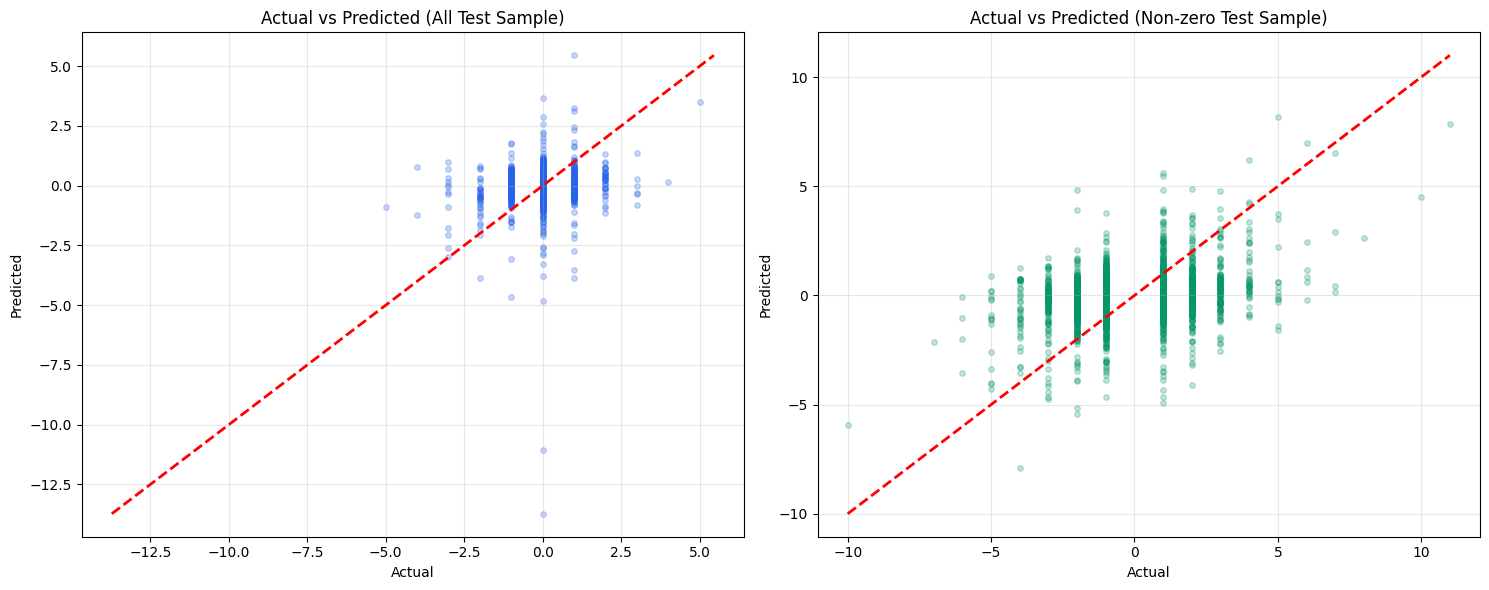

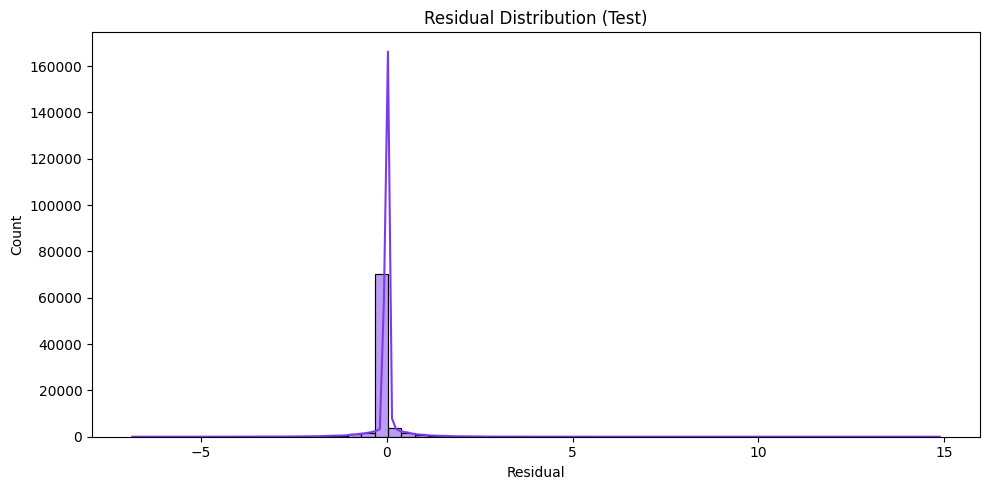

In [ ]:
# ARIMAX diagnostics plots
sample_n = min(8000, len(test_df))
sample = test_df.sample(n=sample_n, random_state=42)

nz = test_df[test_df['y_true'] != 0]
if len(nz) > 0:
    nz_sample = nz.sample(n=min(8000, len(nz)), random_state=42)
else:
    nz_sample = pd.DataFrame(columns=test_df.columns)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(sample['y_true'], sample['y_pred'], alpha=0.25, s=16, color='#2563eb')
mn = float(min(sample['y_true'].min(), sample['y_pred'].min()))
mx = float(max(sample['y_true'].max(), sample['y_pred'].max()))
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted (All Test Sample)')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].grid(alpha=0.3)

if len(nz_sample) > 0:
    axes[1].scatter(nz_sample['y_true'], nz_sample['y_pred'], alpha=0.25, s=16, color='#059669')
    mn2 = float(min(nz_sample['y_true'].min(), nz_sample['y_pred'].min()))
    mx2 = float(max(nz_sample['y_true'].max(), nz_sample['y_pred'].max()))
    axes[1].plot([mn2, mx2], [mn2, mx2], 'r--', lw=2)
    axes[1].set_title('Actual vs Predicted (Non-zero Test Sample)')
    axes[1].set_xlabel('Actual')
    axes[1].set_ylabel('Predicted')
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No non-zero rows', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
resid = test_df['y_true'].to_numpy() - test_df['y_pred'].to_numpy()
sns.histplot(resid, bins=60, kde=True, color='#7c3aed')
plt.title('Residual Distribution (Test)')
plt.xlabel('Residual')
plt.tight_layout()
plt.show()
